# 13 — Expanded LSEG Gemma/FinBERT return robustness

**Objective.** Test whether the fully scored 44-company LSEG headline population carries next-open return information, and whether any conclusion changes when the scorer is Gemma 4 26B rather than the inherited pinned FinBERT comparator.

**Success criteria.** A result is only economically interesting if it survives the declared 18-test IC family, remains positive after the already-used 10 bps/side cost convention, and has a positive five-session block-bootstrap lower bound. This is a retrospective non-pooled robustness arm, not a pristine holdout and not a replacement for Gate F1.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import (  # noqa: E402
    AGGREGATOR_NAMES,
    benjamini_hochberg,
    cross_sectional_daily_ic,
)
from final_experiments.lib.lseg_expanded import (  # noqa: E402
    INFORMATION_BUFFER_MINUTES,
    PRIMARY_FAMILY,
    assert_paired_population,
    build_expanded_aggregation_panel,
    canonical_score_frame,
    evaluate_expanded_arms,
    filter_sensitivity_events,
    load_price_exports,
    load_success_scores,
    map_headlines_to_entry_sessions,
)
from final_experiments.lib.plots import display_label  # noqa: E402

COLLECTION_ROOT = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
FINBERT_SCORES = COLLECTION_ROOT / "headline_scores_finbert4556_cacheonly_20260803.csv"
GEMMA_SCORES = COLLECTION_ROOT / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
SECTOR33_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
ADD11_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv"
OUTPUT = REPO_ROOT / "final_experiments/outputs/13_lseg_44_gemma_robustness"
OUTPUT.mkdir(parents=True, exist_ok=True)
FILTER_FAMILY = "two scorers x four pre-declared metadata filters x mean continuous h1; BH-FDR q=0.05"
SEED = 20260805

print("population unit: unique normalized headline at first observed timestamp")
print(f"timing: first exchange open >= timestamp + {INFORMATION_BUFFER_MINUTES} minutes")
print("target: split-adjusted, non-dividend-adjusted open-to-next-open raw return")
print("primary family:", PRIMARY_FAMILY)
print("status: retrospective exploratory, LSEG-only, never pooled with FNSPID")

population unit: unique normalized headline at first observed timestamp
timing: first exchange open >= timestamp + 15 minutes
target: split-adjusted, non-dividend-adjusted open-to-next-open raw return
primary family: two scorers x nine pre-existing aggregators x h1; BH-FDR q=0.05
status: retrospective exploratory, LSEG-only, never pooled with FNSPID


## 1. Frozen inputs and scorer audit

The OpenRouter checkpoint is append-only. Historical failed attempts remain in the file, but all downstream work selects `status == "success"` and fails unless that produces exactly one valid probability vector for every one of the 888,155 frozen hashes. FinBERT labels are exact-hash inheritances. Canonical associations, flags, and timestamps come from the current merged 44-company population rather than stale metadata retained on some inherited rows.

In [2]:
finbert_raw, finbert_audit = load_success_scores(FINBERT_SCORES, scorer="finbert")
gemma_raw, gemma_audit = load_success_scores(GEMMA_SCORES, scorer="gemma4_26b")
paired = assert_paired_population(finbert_raw, gemma_raw)

input_audit = pd.DataFrame(
    [
        {
            **{k: v for k, v in audit.items() if k != "status_counts"},
            **{f"status_{k}": v for k, v in audit["status_counts"].items()},
        }
        for audit in (finbert_audit, gemma_audit)
    ]
)
metadata_audit = pd.DataFrame(
    [
        {"field": field, "finbert_seed_rows_differing_from_canonical": count}
        for field, count in paired.attrs["finbert_seed_metadata_mismatch_counts"].items()
    ]
)
input_audit.to_csv(OUTPUT / "input_score_audit.csv", index=False)
metadata_audit.to_csv(OUTPUT / "canonical_metadata_audit.csv", index=False)
display(input_audit)
display(metadata_audit)

,scorer,rows_including_historical_attempts,unique_successes,duplicate_successes,invalid_success_probabilities,reported_cost_usd_sum,output_sha256,status_success,status_api_error,status_invalid_output,status_malformed_response
0,finbert,888155,888155,0,0,0.000000,737287a167dea8f3a7f03c53f020d6606a4f0554dc105b...,888155,NaN,NaN,NaN
1,gemma4_26b,889103,888155,0,0,33.615345,afb2d9c3029c4fba4fce3600218233a02d14051788f873...,888155,919.0,27.0,2.0


,field,finbert_seed_rows_differing_from_canonical
0,matched_symbols,4222
1,first_timestamp,5805
2,explicit_target,269
3,contextual,269
4,market_price_technical,0


## 2. Price and timing coverage

Both LSEG price exports use exchange/manual/capital-change corrections and do not back-adjust dividends. Precise timestamps permit a stronger rule than Notebook 11's date-only mapping: a headline is usable at an open only when the open is at least 15 minutes later. The next observed open supplies the one-session outcome.

In [3]:
prices = load_price_exports(SECTOR33_PRICES, ADD11_PRICES)
price_coverage = (
    prices.groupby("symbol", as_index=False)
    .agg(
        first_session=("session_date", "min"),
        last_session=("session_date", "max"),
        sessions=("session_date", "size"),
    )
    .sort_values("symbol")
)
price_coverage.to_csv(OUTPUT / "price_coverage.csv", index=False)
display(price_coverage)
print(f"price panel: {len(prices):,} rows; {prices['symbol'].nunique()} companies")

,symbol,first_session,last_session,sessions
0,AAPL,2025-10-21,2026-07-02,175
1,ABBV,2025-10-21,2026-07-02,175
2,AEP,2025-10-21,2026-07-02,175
3,AMT,2025-10-20,2026-07-02,176
4,AMZN,2025-10-21,2026-07-02,175
5,AVGO,2025-10-21,2026-07-02,175
6,BA,2025-10-21,2026-07-02,175
7,BAC,2025-10-21,2026-07-02,175
8,CAT,2025-10-21,2026-07-02,175
9,COP,2025-10-21,2026-07-02,175


price panel: 7,708 rows; 44 companies


## 3. Canonical headline-to-open panels

The 888,155 hash population expands to company associations where a headline matched more than one frozen name. Within each scorer, the nine aggregation rules are exactly those already used in Notebook 03. `strongest_event` cannot prefer non-recaps because the headline-only corpus has no validated recap field; all rows therefore enter that rule at the same recap priority.

In [4]:
canonical_scores = {
    "finbert": canonical_score_frame(paired, scorer="finbert"),
    "gemma4_26b": canonical_score_frame(paired, scorer="gemma"),
}
mapped_events = {scorer: map_headlines_to_entry_sessions(frame, prices) for scorer, frame in canonical_scores.items()}
panels = {scorer: build_expanded_aggregation_panel(events, prices) for scorer, events in mapped_events.items()}

grain = pd.DataFrame(
    [
        {
            "scorer": scorer,
            "unique_headlines": frame["headline_sha256"].nunique(),
            "company_headline_associations": len(events),
            "firm_open_rows": len(panels[scorer]),
            "priced_firm_open_rows": int(panels[scorer]["raw_open_h1"].notna().sum()),
            "entry_sessions": panels[scorer]["session_date"].nunique(),
            "companies": panels[scorer]["symbol"].nunique(),
        }
        for scorer, frame in canonical_scores.items()
        for events in [mapped_events[scorer]]
    ]
)
grain.to_csv(OUTPUT / "analysis_grain.csv", index=False)
display(grain)

for scorer, panel in panels.items():
    panel.to_parquet(OUTPUT / f"{scorer}_firm_open_aggregators.parquet", index=False)

,scorer,unique_headlines,company_headline_associations,firm_open_rows,priced_firm_open_rows,entry_sessions,companies
0,finbert,888155,929691,7348,7348,167,44
1,gemma4_26b,888155,929691,7348,7348,167,44


,unique_headlines_per_firm_open
count,7348.000000
mean,126.522999
std,144.605832
min,4.000000
25%,54.000000
50%,80.000000
75%,132.000000
90%,265.000000
95%,380.000000
99%,742.120000


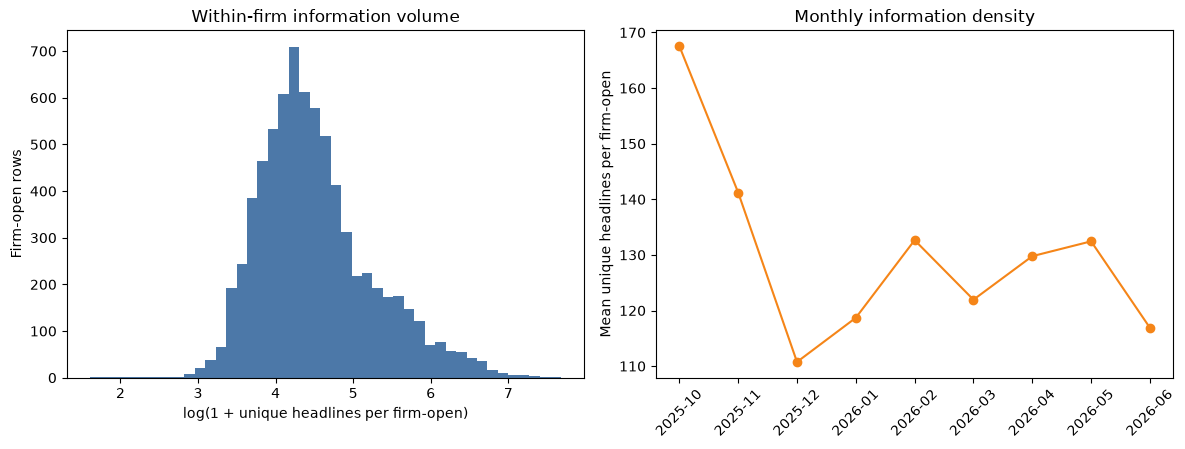

In [5]:
volume = panels["gemma4_26b"][["symbol", "session_date", "unique_headline_count"]].copy()
volume_summary = (
    volume["unique_headline_count"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).rename("unique_headlines_per_firm_open")
)
display(volume_summary.to_frame())
volume_summary.to_csv(OUTPUT / "firm_open_headline_count_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
axes[0].hist(np.log1p(volume["unique_headline_count"]), bins=45, color="#4c78a8")
axes[0].set_xlabel("log(1 + unique headlines per firm-open)")
axes[0].set_ylabel("Firm-open rows")
axes[0].set_title("Within-firm information volume")
monthly = (
    volume.assign(month=volume["session_date"].dt.to_period("M"))
    .groupby("month")
    .agg(
        firm_open_rows=("symbol", "size"),
        mean_unique_headlines=("unique_headline_count", "mean"),
    )
)
axes[1].plot(monthly.index.astype(str), monthly["mean_unique_headlines"], marker="o", color="#f58518")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("Mean unique headlines per firm-open")
axes[1].set_title("Monthly information density")
fig.tight_layout()
fig.savefig(OUTPUT / "expanded_corpus_volume.png", dpi=150)
plt.show()

## 4. Primary 18-arm aggregation family

IC is the mean daily cross-sectional Spearman correlation with HAC(5) inference. BH is applied once across `2 scorers × 9 aggregators × h1`. The fixed portfolio translation uses centred cross-sectional ranks, gross exposure one, at least ten active names, one-session holding, 10 bps per side on half-L1 turnover, and an explicit final liquidation. The five-session circular block bootstrap uses 1,999 replications and seed 20260805.

In [6]:
primary, daily_outputs = evaluate_expanded_arms(
    panels,
    cost_bps_per_side=10.0,
    bootstrap_replications=1_999,
    seed=SEED,
)
primary.to_csv(OUTPUT / "primary_18_arm_results.csv", index=False)
for (scorer, aggregator), daily in daily_outputs.items():
    daily.to_csv(OUTPUT / f"daily_{scorer}_{aggregator}.csv", index=False)

show_columns = [
    "scorer",
    "aggregator",
    "ic",
    "ic_se",
    "ic_p",
    "bh_reject_ic_q05",
    "sharpe_gross",
    "sharpe_net",
    "breakeven_bps_per_side",
    "bootstrap_net_ci_low",
    "bootstrap_net_ci_high",
]
display(primary[show_columns].sort_values("ic_p").style.format(precision=4))

,scorer,aggregator,ic,ic_se,ic_p,bh_reject_ic_q05,sharpe_gross,sharpe_net,breakeven_bps_per_side,bootstrap_net_ci_low,bootstrap_net_ci_high
15,gemma4_26b,strongest_event,0.0346,0.0210,0.0992,False,1.2503,-2.1194,3.7087,-0.0019,0.0002
6,finbert,strongest_event,0.0148,0.0126,0.2405,False,0.8747,-3.4866,2.0080,-0.0014,-0.0004
16,gemma4_26b,attention_log_n,-0.0178,0.0181,0.3259,False,-1.3370,-4.3203,-4.5121,-0.0023,-0.0007
12,gemma4_26b,trimmed_mean,-0.0150,0.0175,0.3927,False,-1.1394,-4.1732,-3.7882,-0.0022,-0.0006
10,gemma4_26b,mean_continuous,-0.0151,0.0177,0.3937,False,-1.1897,-4.1952,-3.9917,-0.0022,-0.0006
9,gemma4_26b,mean_hard_label,-0.0146,0.0174,0.4015,False,-1.2170,-4.3028,-3.9784,-0.0022,-0.0006
11,gemma4_26b,median_continuous,-0.0120,0.0155,0.4367,False,-0.9162,-3.9880,-3.0012,-0.0020,-0.0005
17,gemma4_26b,decayed_state,-0.0126,0.0171,0.4612,False,-0.9500,-2.7738,-5.2500,-0.0016,-0.0002
7,finbert,attention_log_n,-0.0114,0.0180,0.5262,False,-1.0635,-4.2159,-3.4058,-0.0021,-0.0006
4,finbert,negative_share,0.0099,0.0177,0.5768,False,-1.3222,-4.5349,-4.1178,-0.0022,-0.0007


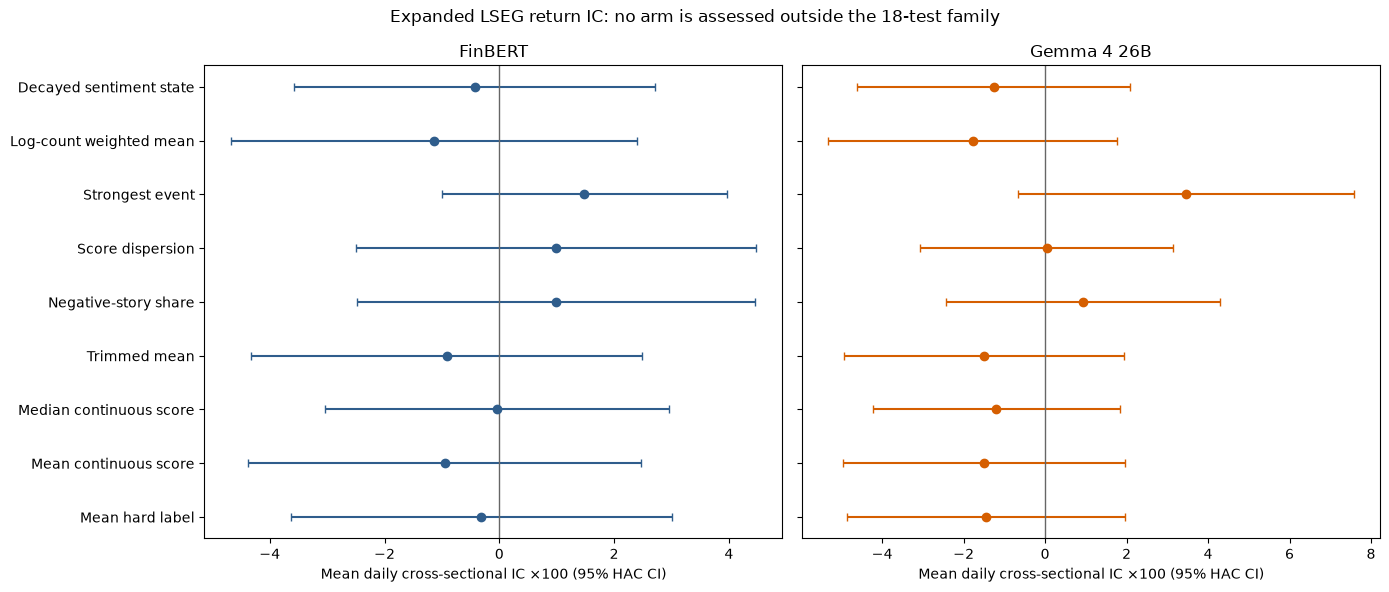

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 6.0), sharey=True)
for ax, scorer in zip(axes, ("finbert", "gemma4_26b"), strict=True):
    table = primary.loc[primary["scorer"].eq(scorer)].set_index("aggregator").reindex(AGGREGATOR_NAMES)
    y = np.arange(len(table))
    ax.errorbar(
        100 * table["ic"],
        y,
        xerr=1.96 * 100 * table["ic_se"],
        fmt="o",
        color="#2f5d8c" if scorer == "finbert" else "#d55e00",
        capsize=3,
    )
    ax.axvline(0, color="#666", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels([display_label(name) for name in table.index])
    ax.set_xlabel("Mean daily cross-sectional IC ×100 (95% HAC CI)")
    ax.set_title("FinBERT" if scorer == "finbert" else "Gemma 4 26B")
fig.suptitle("Expanded LSEG return IC: no arm is assessed outside the 18-test family")
fig.tight_layout()
fig.savefig(OUTPUT / "primary_ic_comparison.png", dpi=150)
plt.show()

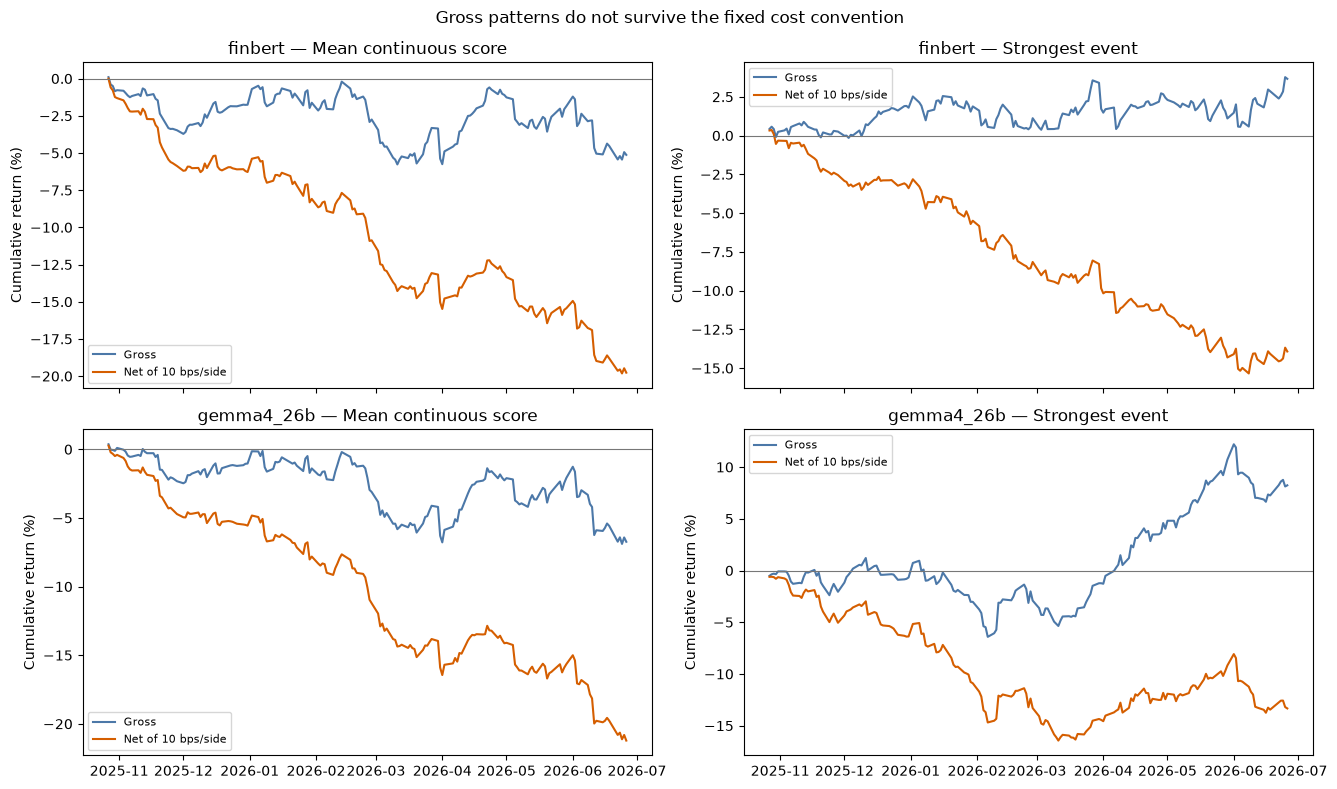

In [8]:
focus_arms = ("mean_continuous", "strongest_event")
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.0), sharex=True)
for row, scorer in enumerate(("finbert", "gemma4_26b")):
    for col, aggregator in enumerate(focus_arms):
        daily = daily_outputs[(scorer, aggregator)].copy()
        gross_equity = (1 + daily["gross_return"]).cumprod() - 1
        net_equity = (1 + daily["net_return"]).cumprod() - 1
        ax = axes[row, col]
        ax.plot(daily["session_date"], 100 * gross_equity, label="Gross", color="#4c78a8")
        ax.plot(daily["session_date"], 100 * net_equity, label="Net of 10 bps/side", color="#d55e00")
        ax.axhline(0, color="#777", lw=0.8)
        ax.set_title(f"{scorer} — {display_label(aggregator)}")
        ax.set_ylabel("Cumulative return (%)")
        ax.legend(fontsize=8)
fig.suptitle("Gross patterns do not survive the fixed cost convention")
fig.tight_layout()
fig.savefig(OUTPUT / "focus_arm_equity.png", dpi=150)
plt.show()

## 5. Pre-declared metadata-filter sensitivity

This separate eight-test family changes only the population filter and keeps the continuous-mean aggregator fixed: all unique headlines, single-company associations, explicit single-company headlines, and exclusion of the heuristic market/price/technical class. These metadata flags are rules-based and not human validated, so this is sensitivity analysis rather than a promoted filtering result.

In [9]:
filter_rows = []
for scorer, events in mapped_events.items():
    for filter_name, filtered_events in filter_sensitivity_events(events).items():
        panel = build_expanded_aggregation_panel(filtered_events, prices)
        use = panel.loc[panel["raw_open_h1"].notna()]
        stats = cross_sectional_daily_ic(use["mean_continuous"], use["raw_open_h1"], use["session_date"], min_names=3, hac_lags=5)
        filter_rows.append(
            {
                "scorer": scorer,
                "filter": filter_name,
                "company_headline_associations": len(filtered_events),
                "firm_open_rows": len(panel),
                **stats,
            }
        )
filter_sensitivity = pd.DataFrame(filter_rows)
filter_sensitivity["bh_reject_q05"] = benjamini_hochberg(filter_sensitivity["p"].fillna(1.0).tolist())
filter_sensitivity["multiplicity_family"] = FILTER_FAMILY
filter_sensitivity.to_csv(OUTPUT / "filter_sensitivity_ic.csv", index=False)
display(filter_sensitivity.sort_values("p").style.format(precision=4))

,scorer,filter,company_headline_associations,firm_open_rows,n,n_clusters,n_dates_total,min_names,hac_lags,inference,ic,se,t,p,bh_reject_q05,multiplicity_family
7,gemma4_26b,exclude_market_price_technical,776520,7348,7348,167,167,3,5,mean_daily_cross_sectional_spearman_hac,-0.0140,0.0152,-0.9229,0.3560,False,two scorers x four pre-declared metadata filters x mean continuous h1; BH-FDR q=0.05
4,gemma4_26b,all_unique_headlines,929691,7348,7348,167,167,3,5,mean_daily_cross_sectional_spearman_hac,-0.0151,0.0177,-0.8528,0.3937,False,two scorers x four pre-declared metadata filters x mean continuous h1; BH-FDR q=0.05
5,gemma4_26b,single_company,859466,7348,7348,167,167,3,5,mean_daily_cross_sectional_spearman_hac,-0.0139,0.0177,-0.7879,0.4308,False,two scorers x four pre-declared metadata filters x mean continuous h1; BH-FDR q=0.05
6,gemma4_26b,explicit_single_company,723658,7348,7348,167,167,3,5,mean_daily_cross_sectional_spearman_hac,-0.0114,0.0180,-0.6340,0.5261,False,two scorers x four pre-declared metadata filters x mean continuous h1; BH-FDR q=0.05
0,finbert,all_unique_headlines,929691,7348,7348,167,167,3,5,mean_daily_cross_sectional_spearman_hac,-0.0095,0.0175,-0.5439,0.5865,False,two scorers x four pre-declared metadata filters x mean continuous h1; BH-FDR q=0.05
1,finbert,single_company,859466,7348,7348,167,167,3,5,mean_daily_cross_sectional_spearman_hac,-0.0073,0.0178,-0.4107,0.6813,False,two scorers x four pre-declared metadata filters x mean continuous h1; BH-FDR q=0.05
2,finbert,explicit_single_company,723658,7348,7348,167,167,3,5,mean_daily_cross_sectional_spearman_hac,-0.0063,0.0181,-0.3484,0.7275,False,two scorers x four pre-declared metadata filters x mean continuous h1; BH-FDR q=0.05
3,finbert,exclude_market_price_technical,776520,7348,7348,167,167,3,5,mean_daily_cross_sectional_spearman_hac,-0.0044,0.0144,-0.3048,0.7606,False,two scorers x four pre-declared metadata filters x mean continuous h1; BH-FDR q=0.05


## 6. Result and interpretation boundary

In [10]:
bh_survivors = primary.loc[primary["bh_reject_ic_q05"]]
economically_viable = primary.loc[
    primary["sharpe_net"].gt(0) & primary["breakeven_bps_per_side"].ge(10.0) & primary["bootstrap_net_ci_low"].gt(0)
]
best_ic = primary.sort_values("ic_p").iloc[0]
best_gross = primary.sort_values("sharpe_gross", ascending=False).iloc[0]

result_summary = pd.DataFrame(
    [
        {"metric": "BH-surviving primary arms", "value": len(bh_survivors)},
        {"metric": "economically viable primary arms", "value": len(economically_viable)},
        {"metric": "smallest-p arm", "value": f"{best_ic.scorer}/{best_ic.aggregator}"},
        {"metric": "smallest-p IC", "value": best_ic.ic},
        {"metric": "smallest-p raw p", "value": best_ic.ic_p},
        {"metric": "best gross-Sharpe arm", "value": f"{best_gross.scorer}/{best_gross.aggregator}"},
        {"metric": "best gross Sharpe", "value": best_gross.sharpe_gross},
        {"metric": "that arm net Sharpe", "value": best_gross.sharpe_net},
        {"metric": "that arm break-even bps/side", "value": best_gross.breakeven_bps_per_side},
        {"metric": "filter-family BH survivors", "value": int(filter_sensitivity["bh_reject_q05"].sum())},
    ]
)
result_summary.to_csv(OUTPUT / "result_summary.csv", index=False)
display(result_summary)

if len(bh_survivors) == 0 and len(economically_viable) == 0:
    print("RESULT: no return arm survives multiplicity or the fixed economic-viability gate.")
else:
    print("RESULT: inspect surviving rows before any claim; this remains retrospective exploratory evidence.")

,metric,value
0,BH-surviving primary arms,0
1,economically viable primary arms,0
2,smallest-p arm,gemma4_26b/strongest_event
3,smallest-p IC,0.034612
4,smallest-p raw p,0.09919
5,best gross-Sharpe arm,gemma4_26b/strongest_event
6,best gross Sharpe,1.250252
7,that arm net Sharpe,-2.119365
8,that arm break-even bps/side,3.708707
9,filter-family BH survivors,0


RESULT: no return arm survives multiplicity or the fixed economic-viability gate.


In [11]:
manifest = {
    "status": "RETROSPECTIVE_EXPLORATORY_NON_POOLED_ROBUSTNESS",
    "population": {
        "unique_normalized_headlines": 888_155,
        "companies": 44,
        "company_headline_associations": int(len(mapped_events["gemma4_26b"])),
        "first_entry_session": str(panels["gemma4_26b"]["session_date"].min().date()),
        "last_entry_session": str(panels["gemma4_26b"]["session_date"].max().date()),
    },
    "scorers": ["ProsusAI/finbert@4556d130", "google/gemma-4-26b-a4b-it via DeepInfra FP8"],
    "timing": {
        "unit": "unique normalized headline first timestamp",
        "information_buffer_minutes": INFORMATION_BUFFER_MINUTES,
        "entry": "first XNYS open at least buffer minutes after first timestamp",
        "return": "split-adjusted non-dividend-adjusted open-to-next-open raw price return",
    },
    "families": {"primary": PRIMARY_FAMILY, "filter_sensitivity": FILTER_FAMILY},
    "portfolio": {
        "position_mode": "centred cross-sectional rank, gross exposure one",
        "minimum_names": 10,
        "cost_bps_per_side": 10.0,
        "final_liquidation": True,
        "bootstrap": {"block_length_sessions": 5, "replications": 1_999, "seed": SEED},
    },
    "results": {
        "primary_bh_survivors": int(len(bh_survivors)),
        "economically_viable_arms": int(len(economically_viable)),
        "filter_family_bh_survivors": int(filter_sensitivity["bh_reject_q05"].sum()),
        "smallest_p_arm": f"{best_ic.scorer}/{best_ic.aggregator}",
        "smallest_p_ic": float(best_ic.ic),
        "smallest_p_raw_p": float(best_ic.ic_p),
        "best_gross_sharpe_arm": f"{best_gross.scorer}/{best_gross.aggregator}",
        "best_gross_sharpe": float(best_gross.sharpe_gross),
        "best_gross_arm_net_sharpe": float(best_gross.sharpe_net),
        "best_gross_arm_breakeven_bps_per_side": float(best_gross.breakeven_bps_per_side),
    },
    "limitations": [
        "retrospective eight-month robustness snapshot; not a pristine holdout",
        "raw company return is not market-adjusted",
        "unique-headline first-occurrence unit removes repeated exact text by construction",
        "headline-only corpus has no validated story-family, recap, or human relevance labels",
        "human sentiment audit remains outstanding; model agreement is not accuracy",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_EXPLORATORY_NON_POOLED_ROBUSTNESS",
  "population": {
    "unique_normalized_headlines": 888155,
    "companies": 44,
    "company_headline_associations": 929691,
    "first_entry_session": "2025-10-27",
    "last_entry_session": "2026-06-26"
  },
  "scorers": [
    "ProsusAI/finbert@4556d130",
    "google/gemma-4-26b-a4b-it via DeepInfra FP8"
  ],
  "timing": {
    "unit": "unique normalized headline first timestamp",
    "information_buffer_minutes": 15,
    "entry": "first XNYS open at least buffer minutes after first timestamp",
    "return": "split-adjusted non-dividend-adjusted open-to-next-open raw price return"
  },
  "families": {
    "primary": "two scorers x nine pre-existing aggregators x h1; BH-FDR q=0.05",
    "filter_sensitivity": "two scorers x four pre-declared metadata filters x mean continuous h1; BH-FDR q=0.05"
  },
  "portfolio": {
    "position_mode": "centred cross-sectional rank, gross exposure one",
    "minimum_names": 10,
    "cos

## Next step

Preserve this result whether null or positive. Do not tune thresholds, filters, horizons, or costs on this same eight-month block. The next formal dissertation action remains Gate F1 plus the outstanding blinded human audit; any future LSEG confirmation must use a separately frozen later or earlier window.